In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from statsmodels.regression.linear_model import OLS
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.patches import Rectangle
from functions import feature_selection, add_cross_terms, bootstrap_LOO
from matplotlib.patches import Rectangle
from statsmodels.regression.linear_model import OLS, WLS

In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')

#Keep only Lec, CG, WG, OG, and SQ codes (see paper for discussion of feature selection)
#these will be input features for the model
###################################################
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#############################################
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [3]:
#trying putting back in dropout

In [4]:
#feature selection and aic functions are called in from functions.py

#pick number of bootstrap samples and number of best fits to use for LOO predictions
bootstrap_n = 50
n_fits = 10
#pick number of feature selection order randomizations to use for each LOO fit
feature_selection_its = 600

#create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
LOO_predictions = np.zeros(( n_fits, bootstrap_n, data.shape[0]))
LOO_weights = np.zeros(( n_fits, bootstrap_n, data.shape[0], data.shape[1]))
good_fit_AICs = np.zeros(( n_fits, data.shape[0] ))


#perform leave-one-out cross-validation for each of the best fits
for k in range(data.shape[0]): 
    print(f'LOO iteration {k} of {data.shape[0]}')
    cut_data = np.delete(data, k, axis=0)
    cut_truth = np.delete(target, k, axis=0)
    cut_weights = np.delete(1/ES_variance, k, axis=0)
    keepers, AICs, good_fits = feature_selection(cut_data, cut_truth, its=feature_selection_its, prt = False, num_choose = n_fits,)# weights = cut_weights)
    #print(AICs[good_fits])

    good_fit_AICs[:, k] = AICs[good_fits]
    LOO_predictions[:, :, k], LOO_weights[:, :, k, :] = bootstrap_LOO(data, target, keepers, good_fits, 
                                                                      bootstrap_n=bootstrap_n, leave_out = k, )#weights = 1/ES_variance   )
    

    #save predictions to npy after each iteration
    np.save('weights/LOO_feature_selection_predictions_WLS.npy', LOO_predictions)
    np.save('weights/LOO_feature_selection_weights_WLS.npy', LOO_weights)
    np.save('weights/LOO_feature_selection_AICs_WLS.npy', good_fit_AICs)


LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

(array([  1.,   0.,  51.,   0.,   0., 620.,   0.,  17.,   0.,   1.]),
 array([10. , 10.4, 10.8, 11.2, 11.6, 12. , 12.4, 12.8, 13.2, 13.6, 14. ]),
 <BarContainer object of 10 artists>)

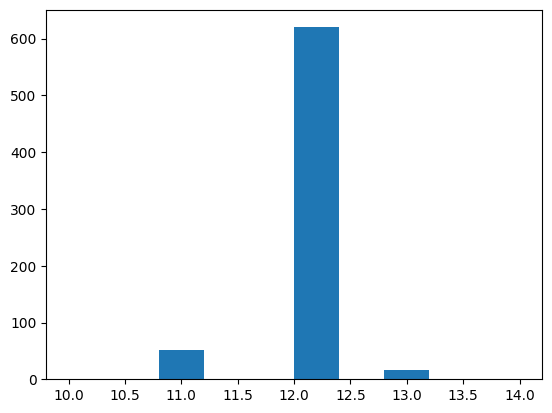

In [5]:
plt.hist(np.sum(LOO_weights > 0, axis = ( 3))[:, 0].flatten())
#plt.scatter(np.sum(LOO_weights > 0, axis = (3))[:, 0].flatten(), 

In [6]:
def AIC_weights(AICs):
    exp_AICs = np.exp(-0.5 * (AICs - np.min(AICs)))
    return exp_AICs / np.sum(exp_AICs)

In [7]:

#LOO_predictions = np.load('weights/LOO_feature_selection_predictions_WLS.npy')
#LOO_weights = np.load('weights/LOO_feature_selection_weights_WLS.npy')
#LOO_predictions.shape

In [8]:
plt.hist(aic_weights[:5].flatten())

NameError: name 'aic_weights' is not defined

In [9]:
aic_weights = np.zeros((10, 1, data.shape[0]))
for i in range(data.shape[0]):
    aic_weights[:, :, i] = AIC_weights(good_fit_AICs[:, i]).reshape(-1, 1)
LOO_feature_means = np.sum(aic_weights.reshape(n_fits, 1, -1) * LOO_predictions, axis=0)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
#LOO_predictions.shape

#LOO_predictions_mean = np.mean(LOO_predictions, axis = (0, 1))
#LOO_predictions_std = np.std(LOO_predictions, axis = (0, 1))

In [10]:
LOO_feature_means.shape

(50, 69)

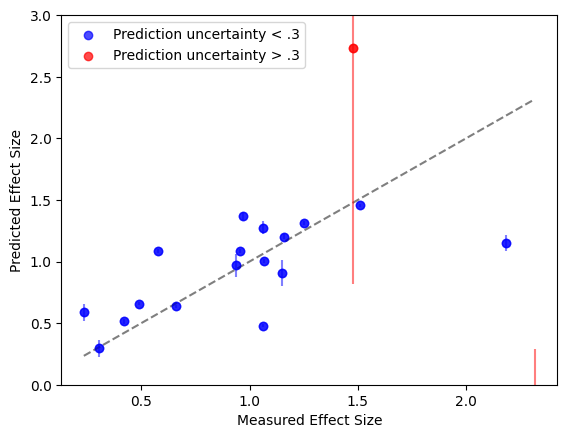

R^2: 0.000
Mean absolute error: 0.5888
-----
R^2 removing high uncertainty: 0.469
MAE removing high uncertainty: 0.2474


In [11]:
#The sundstrom dataset has no repeating instructors or institutions except the following
repeat_institutions = ['ISLE_Course3', 'ISLE_Course4', 'ISLE_Course1', 'PeerInstruction_Course3', 'PeerInstruction_Course4',]

#to make sure there is no overfitting due to instructor or institution
#We remove the repeat institutions from the dataset and re-run LOO on the remaining Sundstrom data
sundstrom_data = codes_and_CIs[codes_and_CIs['Source'] == 'Sundstrom et al. 2025']
sundstrom_classes_no_repeat = sundstrom_data[~sundstrom_data['Course'].isin(repeat_institutions)]

#find the index of those classes in the original data
no_repeat_index = np.where(codes_and_CIs['Course'].isin(sundstrom_classes_no_repeat['Course']))[0]

##plotting LOO predictions with error bars representing uncertainty across different fits
x, y = target[no_repeat_index], LOO_predictions_mean[no_repeat_index]

no_repeat_stds = LOO_predictions_std[no_repeat_index]
plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

where_low_error = np.where(no_repeat_stds < .3)
where_high_error = np.where(no_repeat_stds >= .3)
low_x, low_y = x[where_low_error], y[where_low_error]
high_x, high_y = x[where_high_error], y[where_high_error]

m, b = np.polyfit(x, y, 1)
xi = np.linspace(np.min(x), np.max(x), 100)


plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
plt.errorbar(low_x, low_y, yerr=no_repeat_stds[where_low_error], fmt='o', color='blue', alpha=0.5)

plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
plt.errorbar(high_x, high_y, yerr=no_repeat_stds[where_high_error], fmt='o', color='red', alpha=0.5)

plt.xlabel(f'Measured Effect Size')
plt.ylabel(f'Predicted Effect Size')
plt.ylim(0, 3)
#plt.title(f'Leave-One-Out Predictions vs Target')
plt.legend()
plt.savefig('Figs/LOO.png', dpi=300)
plt.show()

print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
print('-----')
print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')



(69,)


(-1.0, 4.0)

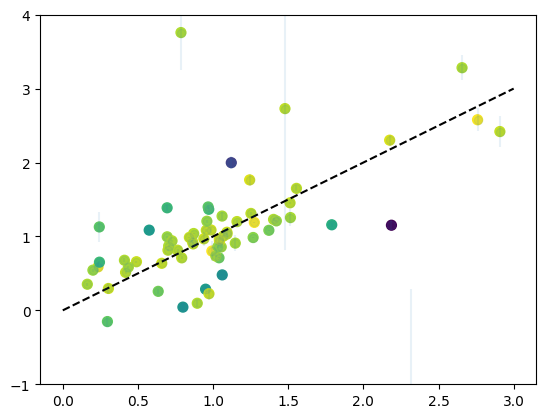

In [12]:
#all_preds = LOO_weights @ data.T
#get only diagonal in axis 2 and 3
#LOO_preds = np.diagonal(all_preds, offset=0, axis1=2, axis2=3)
#LOO_pred_features = np.squeeze(LOO_preds.reshape(-1, 1))
#LOO_pred_features.shape

#LOO_predictions_means = np.mean(LOO_pred_features, axis=0)
#LOO_predictions_stds = np.std(LOO_pred_features, axis=0)
print(LOO_predictions_mean.shape)
mins = np.min(good_fit_AICs, axis=0)
plt.errorbar(target, LOO_predictions_mean, yerr=LOO_predictions_std, fmt='o',alpha = .1)
plt.scatter(target, LOO_predictions_mean, c=mins, cmap='viridis', s=50)
plt.plot([0, 3], [0, 3], 'k--')
plt.ylim(-1, 4)

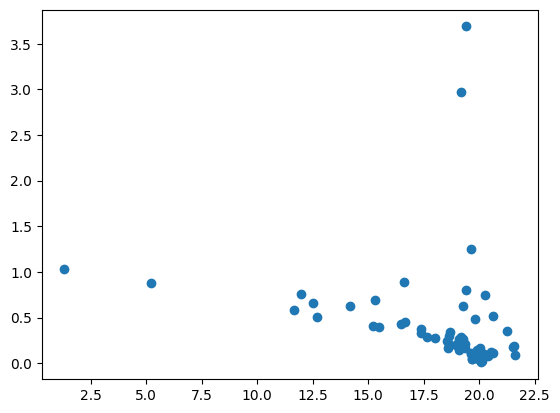

In [13]:
plt.scatter(mins, np.abs(LOO_predictions_mean - target))

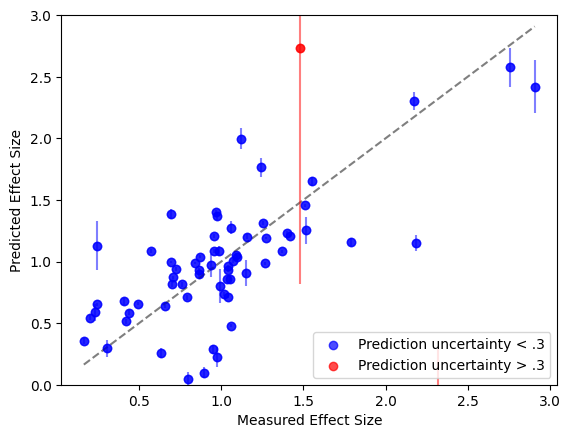

R^2: 0.217
Mean absolute error: 0.3922
-----
R^2 removing high uncertainty: 0.605
MAE removing high uncertainty: 0.2901


In [14]:


##plotting LOO predictions with error bars representing uncertainty across different fits
x, y = target, LOO_predictions_mean
plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

where_low_error = np.where(LOO_predictions_std < .3)
where_high_error = np.where(LOO_predictions_std >= .3)
low_x, low_y = x[where_low_error], y[where_low_error]
high_x, high_y = x[where_high_error], y[where_high_error]

m, b = np.polyfit(x, y, 1)
xi = np.linspace(np.min(x), np.max(x), 100)


plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

plt.xlabel(f'Measured Effect Size')
plt.ylabel(f'Predicted Effect Size')
plt.ylim(0, 3)
#plt.title(f'Leave-One-Out Predictions vs Target')
plt.legend()
plt.savefig('Figs/LOO.png', dpi=300)
plt.show()

print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
print('-----')
print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')

MAE by field:
Physics MAE: 0.2803
Biology MAE: 0.3119
Astronomy MAE: 0.2618

MAE by class size (N):
N < 50 MAE: 0.3000
50 < N < 150 MAE: 0.2908
N > 150 MAE: 0.2920


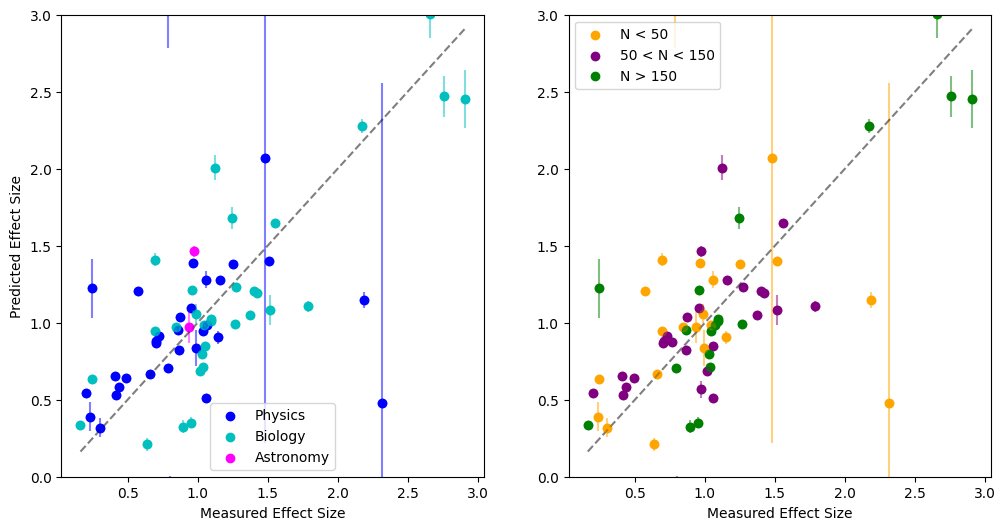

In [ ]:
x, y = target, LOO_predictions_mean
fields = codes_and_CIs['Field'].values
Ns = codes_and_CIs['N'].values


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
print('MAE by field:')
#show points colored by field
for field, color in zip(np.unique(fields)[::-1], ['b', 'c','magenta', ]):
    field_x = x[fields == field]
    field_y = y[fields == field]
    field_err = LOO_predictions_std[fields == field]
    ax[0].scatter(field_x, field_y,  c = color, label=field, )
    ax[0].errorbar(field_x, field_y, yerr=field_err, fmt='o',  color=color, alpha = .5)
    field_reliable = np.where(field_err < .3)
    print(f'{field} MAE: {np.mean(np.abs(field_y[field_reliable]-field_x[field_reliable])):.4f}')
print('')

ax[0].plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)
ax[0].set_xlabel(f'Measured Effect Size')
ax[0].set_ylabel(f'Predicted Effect Size')
ax[0].legend()
#ax[0].set_title(f'LOO Predictions vs Target by Field')
ax[0].set_ylim(0, 3)

#separately plot N < 50  50 < N < 100, and N > 100
N_labels = ['N < 50', '50 < N < 150', 'N > 150']
print('MAE by class size (N):')
for N_range, color, label, i in zip([[0, 50], [50, 150],  [150, np.inf]], ['orange', 'purple', 'g'], N_labels, range(3)):
    where = (Ns > N_range[0]) & (Ns <= N_range[1])
    range_x = x[where]
    range_y = y[where]
    range_err = LOO_predictions_std[where]
    ax[1].scatter(range_x, range_y,  color=color,label = label,)
    ax[1].errorbar(range_x, range_y, yerr=range_err, fmt='o', color=color,  alpha = .5)
    print(f'{label} MAE: {np.mean(np.abs(range_y[range_err < .3]-range_x[range_err < .3])):.4f}')
ax[1].legend()
#ax[1].set_title(f'LOO Predictions vs Target by Class Size (N)')
ax[1].plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)
ax[1].set_xlabel(f'Measured Effect Size')
ax[1].set_ylim(0, 3)
plt.savefig('Figs/LOO_N_Field.png', dpi=300)
plt.show()
